# 07 — Dependência e Independência Linear (LI e LD)
**Referência:** Boldrini et al., Seção 4.5, p. 114–116

---

## 7.1 Motivação

Quando algum vetor de um conjunto pode ser obtido como CL dos outros, ele é **redundante** — traz informação que já estava lá. Esse conjunto é **Linearmente Dependente (LD)**.

Quando nenhum vetor é redundante, o conjunto é **Linearmente Independente (LI)** — cada vetor traz algo novo.

---

## 7.2 Definição (Boldrini, p. 114)

O conjunto $\{v_1, \ldots, v_n\}$ é **LI** se:

$$\alpha_1 v_1 + \alpha_2 v_2 + \cdots + \alpha_n v_n = \mathbf{0} \implies \alpha_1 = \alpha_2 = \cdots = \alpha_n = 0$$

Se existir solução com algum $\alpha_i \neq 0$, o conjunto é **LD**.

---

## 7.3 Proposição Útil (Boldrini, p. 115)

$$\{v_1,\ldots,v_n\} \text{ é LD} \iff \text{algum } v_k \text{ é CL dos outros}$$

---

## 7.4 Como Verificar na Prática

Monte os vetores como **colunas** de uma matriz $M$ e calcule o posto:

$$\text{posto}(M) = n \implies \text{LI} \qquad \text{posto}(M) < n \implies \text{LD}$$


In [16]:
from sympy import Matrix, pprint, det
from sympy import init_printing
init_printing(use_unicode=True)

def verificar_LI(vetores, nomes=None):
    '''Verifica LI/LD - vetores como COLUNAS da matriz.'''
    M = Matrix(vetores).T   # cada vetor vira uma coluna
    posto = M.rank()
    n = len(vetores)
    status = "LI ✓" if posto == n else "LD ✗"
    print(f"  Matriz (vetores como colunas):")
    pprint(M)
    print(f"  Posto = {posto}  |  Nº vetores = {n}  →  {status}")
    if posto < n:
        print(f"  (há {n - posto} vetor(es) redundante(s))")
    return posto == n

print("─── Exemplo LI: {(1,1), (0,1)} em ℝ² ───")
verificar_LI([[1,1],[0,1]])

print("\n─── Exemplo LD: {(1,0,0),(0,1,0),(1,1,0)} em ℝ³ ───")
verificar_LI([[1,0,0],[0,1,0],[1,1,0]])


─── Exemplo LI: {(1,1), (0,1)} em ℝ² ───
  Matriz (vetores como colunas):
⎡1  0⎤
⎢    ⎥
⎣1  1⎦
  Posto = 2  |  Nº vetores = 2  →  LI ✓

─── Exemplo LD: {(1,0,0),(0,1,0),(1,1,0)} em ℝ³ ───
  Matriz (vetores como colunas):
⎡1  0  1⎤
⎢       ⎥
⎢0  1  1⎥
⎢       ⎥
⎣0  0  0⎦
  Posto = 2  |  Nº vetores = 3  →  LD ✗
  (há 1 vetor(es) redundante(s))


False

In [17]:
print("─── Exemplo 7.3: {(1,2,0),(0,1,3),(1,0,-6)} ───")
print("Vetores montados como COLUNAS:")
verificar_LI([[1,2,0],[0,1,3],[1,0,-6]])


─── Exemplo 7.3: {(1,2,0),(0,1,3),(1,0,-6)} ───
Vetores montados como COLUNAS:
  Matriz (vetores como colunas):
⎡1  0  1 ⎤
⎢        ⎥
⎢2  1  0 ⎥
⎢        ⎥
⎣0  3  -6⎦
  Posto = 2  |  Nº vetores = 3  →  LD ✗
  (há 1 vetor(es) redundante(s))


False

In [18]:
# ── Via determinante (apenas n×n) ────────────────────
print("─── Verificação via determinante (n×n) ───")
M_li = Matrix([[1, 0], [1, 1]])   # LI
M_ld = Matrix([[1, 2], [2, 4]])   # LD

print(f"det | 1 0 | = {det(M_li)}  ≠ 0  →  LI ✓")
print(f"    | 1 1 |")
print(f"det | 1 2 | = {det(M_ld)}  = 0  →  LD ✗")
print(f"    | 2 4 |")
print("\nRegra: det ≠ 0 ↔ LI  |  det = 0 ↔ LD")


─── Verificação via determinante (n×n) ───
det | 1 0 | = 1  ≠ 0  →  LI ✓
    | 1 1 |
det | 1 2 | = 0  = 0  →  LD ✗
    | 2 4 |

Regra: det ≠ 0 ↔ LI  |  det = 0 ↔ LD


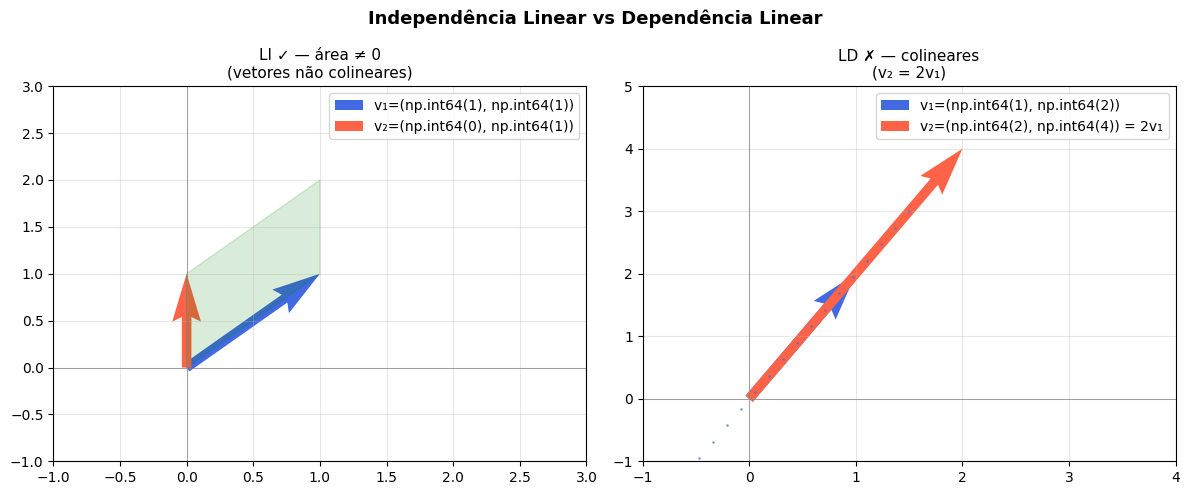

In [19]:
# ── Visualização ─────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

origin = np.array([0, 0])

# LI
ax = axes[0]
v1, v2 = np.array([1, 1]), np.array([0, 1])
ax.quiver(*origin, *v1, color='royalblue', angles='xy', scale_units='xy', scale=1, width=0.018, label=f'v₁={tuple(v1)}')
ax.quiver(*origin, *v2, color='tomato', angles='xy', scale_units='xy', scale=1, width=0.018, label=f'v₂={tuple(v2)}')
ax.fill([0, v1[0], v1[0]+v2[0], v2[0]], [0, v1[1], v1[1]+v2[1], v2[1]], alpha=0.15, color='green')
ax.set_xlim(-1, 3); ax.set_ylim(-1, 3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3); ax.legend()
ax.set_title('LI ✓ — área ≠ 0\n(vetores não colineares)', fontsize=11)

# LD
ax = axes[1]
v1b, v2b = np.array([1, 2]), np.array([2, 4])
for t in np.linspace(-1, 1.5, 20):
    ax.plot([t*v1b[0]], [t*v1b[1]], '.', color='royalblue', ms=2, alpha=0.5)
ax.quiver(*origin, *v1b, color='royalblue', angles='xy', scale_units='xy', scale=1, width=0.018, label=f'v₁={tuple(v1b)}')
ax.quiver(*origin, *v2b, color='tomato', angles='xy', scale_units='xy', scale=1, width=0.018, label=f'v₂={tuple(v2b)} = 2v₁')
ax.set_xlim(-1, 4); ax.set_ylim(-1, 5)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3); ax.legend()
ax.set_title('LD ✗ — colineares\n(v₂ = 2v₁)', fontsize=11)

plt.suptitle('Independência Linear vs Dependência Linear', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📝 Exercícios

1. Verifique se $\{(1,2,3), (0,1,0), (1,0,3)\}$ é LI ou LD.
2. Para que valor de $k$ o conjunto $\{(1,k), (2,4)\}$ é LD?
3. Um conjunto contendo o vetor nulo sempre é LD. Prove ou dê contraexemplo.


In [20]:
from sympy import Matrix, symbols, solve, det

# Ex. 1
print("Ex.1:", "LI ✓" if Matrix([[1,2,3],[0,1,0],[1,0,3]]).T.rank() == 3 else "LD ✗")

# Ex. 2
k = symbols('k')
M = Matrix([[1, 2], [k, 4]])
eq = det(M)
sol_k = solve(eq, k)
print(f"Ex.2: k = {sol_k}  (det = {eq} = 0)")

# Ex. 3
print("Ex.3: se 0 ∈ {v1,...,vn}, então 1·0 + 0·v2 + ... = 0 com coef não nulo → LD")


Ex.1: LD ✗
Ex.2: k = [2]  (det = 4 - 2*k = 0)
Ex.3: se 0 ∈ {v1,...,vn}, então 1·0 + 0·v2 + ... = 0 com coef não nulo → LD
